In [1]:
# Task 13 - Dashboard Performance Tuning
# PlaceMux Phase 1 Industry Immersion

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import sqlite3

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
df = pd.read_csv("Task_8_Cleaned_Retail_Sales.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (120, 17)


,order_id,order_date,customer_id,customer_name,city,category,product,quantity,unit_price,discount_pct,payment_method,sales_channel,status,gross_sales,discount_amount,net_sales,month
0,O0001,2026-02-05,C011,Vikas Tiwari,Ujjain,electronics,Wireless Mouse,6.0,900.0,0,cash,online,completed,5400.0,0.0,5400.0,2026-02
1,O0002,2026-04-25,C004,Neha Singh,Jabalpur,electronics,Headphones,1.0,1400.0,15,cod,offline,completed,1400.0,210.0,1190.0,2026-04
2,O0003,2026-06-04,C006,Sneha Gupta,Bhopal,electronics,Wireless Mouse,1.0,700.0,20,upi,offline,pending,700.0,140.0,560.0,2026-06
3,O0004,2026-02-28,C005,rohit patel,Ujjain,grocery,Cooking Oil,1.0,160.0,0,upi,online,cancelled,160.0,0.0,160.0,2026-02
4,O0005,2026-12-06,C003,AMIT KHAN,Rewa,grocery,Rice Bag,5.0,950.0,5,cash,online,cancelled,4750.0,237.5,4512.5,2026-12


In [4]:
#Step 3 — Create a SQL database
# Step 3: Create SQLite database

import sqlite3

conn = sqlite3.connect("retail_sales.db")

df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite database created successfully!")
print("Table: sales")

# Check table
pd.read_sql_query("SELECT * FROM sales LIMIT 5", conn)

SQLite database created successfully!
Table: sales


,order_id,order_date,customer_id,customer_name,city,category,product,quantity,unit_price,discount_pct,payment_method,sales_channel,status,gross_sales,discount_amount,net_sales,month
0,O0001,2026-02-05,C011,Vikas Tiwari,Ujjain,electronics,Wireless Mouse,6.0,900.0,0,cash,online,completed,5400.0,0.0,5400.0,2026-02
1,O0002,2026-04-25,C004,Neha Singh,Jabalpur,electronics,Headphones,1.0,1400.0,15,cod,offline,completed,1400.0,210.0,1190.0,2026-04
2,O0003,2026-06-04,C006,Sneha Gupta,Bhopal,electronics,Wireless Mouse,1.0,700.0,20,upi,offline,pending,700.0,140.0,560.0,2026-06
3,O0004,2026-02-28,C005,rohit patel,Ujjain,grocery,Cooking Oil,1.0,160.0,0,upi,online,cancelled,160.0,0.0,160.0,2026-02
4,O0005,2026-12-06,C003,AMIT KHAN,Rewa,grocery,Rice Bag,5.0,950.0,5,cash,online,cancelled,4750.0,237.5,4512.5,2026-12


In [5]:
#Step 4 — Check the table structure
# Check database structure

schema = pd.read_sql_query("PRAGMA table_info(sales)", conn)
schema

,cid,name,type,notnull,dflt_value,pk
0,0,order_id,TEXT,0,None,0
1,1,order_date,TEXT,0,None,0
2,2,customer_id,TEXT,0,None,0
3,3,customer_name,TEXT,0,None,0
4,4,city,TEXT,0,None,0
5,5,category,TEXT,0,None,0
6,6,product,TEXT,0,None,0
7,7,quantity,REAL,0,None,0
8,8,unit_price,REAL,0,None,0
9,9,discount_pct,INTEGER,0,None,0


In [6]:
#Step 5 — Baseline query
# Step 5: Baseline performance measurement

import time

query = """
SELECT
    category,
    sales_channel,
    status,
    SUM(quantity) AS total_quantity,
    SUM(gross_sales) AS gross_sales,
    SUM(discount_amount) AS discount_amount,
    SUM(net_sales) AS net_sales,
    COUNT(*) AS total_orders
FROM sales
GROUP BY category, sales_channel, status
ORDER BY net_sales DESC;
"""

start_time = time.perf_counter()

baseline_result = pd.read_sql_query(query, conn)

end_time = time.perf_counter()

baseline_time = end_time - start_time

print(f"Baseline Query Time: {baseline_time:.6f} seconds")
print("Rows returned:", len(baseline_result))

baseline_result

Baseline Query Time: 0.002510 seconds
Rows returned: 24


,category,sales_channel,status,total_quantity,gross_sales,discount_amount,net_sales,total_orders
0,clothing,online,pending,42.0,49600.0,4300.0,45300.0,10
1,electronics,online,completed,49.0,42900.0,3220.0,39680.0,12
2,home,offline,cancelled,28.0,25200.0,2172.5,23027.5,8
3,clothing,offline,cancelled,16.0,21050.0,1085.0,19965.0,5
4,clothing,offline,completed,15.0,20500.0,2050.0,18450.0,4
5,home,online,pending,23.0,18400.0,700.0,17700.0,6
6,grocery,online,cancelled,34.0,18390.0,1519.5,16870.5,11
7,electronics,online,pending,17.0,18050.0,1962.5,16087.5,4
8,clothing,online,completed,14.0,17050.0,1562.5,15487.5,6
9,home,online,cancelled,16.0,13400.0,1300.0,12100.0,4


In [7]:
#Step 6 — Analyze the query execution plan
# Step 6: SQL EXPLAIN QUERY PLAN

explain_query = """
EXPLAIN QUERY PLAN
SELECT
    category,
    sales_channel,
    status,
    SUM(quantity) AS total_quantity,
    SUM(gross_sales) AS gross_sales,
    SUM(discount_amount) AS discount_amount,
    SUM(net_sales) AS net_sales,
    COUNT(*) AS total_orders
FROM sales
GROUP BY category, sales_channel, status
ORDER BY net_sales DESC;
"""

execution_plan = pd.read_sql_query(explain_query, conn)

execution_plan

,id,parent,notused,detail
0,7,0,0,SCAN sales
1,9,0,0,USE TEMP B-TREE FOR GROUP BY
2,76,0,0,USE TEMP B-TREE FOR ORDER BY


In [8]:
#Step 7 — Create a pre-aggregated table
# Step 7: Create a pre-aggregated sales summary table

aggregation_query = """
CREATE TABLE IF NOT EXISTS sales_summary AS
SELECT
    category,
    sales_channel,
    status,
    SUM(quantity) AS total_quantity,
    SUM(gross_sales) AS gross_sales,
    SUM(discount_amount) AS discount_amount,
    SUM(net_sales) AS net_sales,
    COUNT(*) AS total_orders
FROM sales
GROUP BY category, sales_channel, status;
"""

conn.execute("DROP TABLE IF EXISTS sales_summary")
conn.execute(aggregation_query)
conn.commit()

print("Pre-aggregated table created successfully!")

Pre-aggregated table created successfully!


In [9]:
# Verify the pre-aggregated table

summary = pd.read_sql_query(
    "SELECT * FROM sales_summary ORDER BY net_sales DESC",
    conn
)

summary

,category,sales_channel,status,total_quantity,gross_sales,discount_amount,net_sales,total_orders
0,clothing,online,pending,42.0,49600.0,4300.0,45300.0,10
1,electronics,online,completed,49.0,42900.0,3220.0,39680.0,12
2,home,offline,cancelled,28.0,25200.0,2172.5,23027.5,8
3,clothing,offline,cancelled,16.0,21050.0,1085.0,19965.0,5
4,clothing,offline,completed,15.0,20500.0,2050.0,18450.0,4
5,home,online,pending,23.0,18400.0,700.0,17700.0,6
6,grocery,online,cancelled,34.0,18390.0,1519.5,16870.5,11
7,electronics,online,pending,17.0,18050.0,1962.5,16087.5,4
8,clothing,online,completed,14.0,17050.0,1562.5,15487.5,6
9,home,online,cancelled,16.0,13400.0,1300.0,12100.0,4


In [10]:
# Step 8: Measure optimized query performance

optimized_query = """
SELECT
    category,
    sales_channel,
    status,
    total_quantity,
    gross_sales,
    discount_amount,
    net_sales,
    total_orders
FROM sales_summary
ORDER BY net_sales DESC;
"""

start_time = time.perf_counter()

optimized_result = pd.read_sql_query(optimized_query, conn)

end_time = time.perf_counter()

optimized_time = end_time - start_time

print(f"Optimized Query Time: {optimized_time:.6f} seconds")
print("Rows returned:", len(optimized_result))

optimized_result

Optimized Query Time: 0.002659 seconds
Rows returned: 24


,category,sales_channel,status,total_quantity,gross_sales,discount_amount,net_sales,total_orders
0,clothing,online,pending,42.0,49600.0,4300.0,45300.0,10
1,electronics,online,completed,49.0,42900.0,3220.0,39680.0,12
2,home,offline,cancelled,28.0,25200.0,2172.5,23027.5,8
3,clothing,offline,cancelled,16.0,21050.0,1085.0,19965.0,5
4,clothing,offline,completed,15.0,20500.0,2050.0,18450.0,4
5,home,online,pending,23.0,18400.0,700.0,17700.0,6
6,grocery,online,cancelled,34.0,18390.0,1519.5,16870.5,11
7,electronics,online,pending,17.0,18050.0,1962.5,16087.5,4
8,clothing,online,completed,14.0,17050.0,1562.5,15487.5,6
9,home,online,cancelled,16.0,13400.0,1300.0,12100.0,4


In [11]:
# Step 9: Calculate performance improvement

improvement = baseline_time - optimized_time
improvement_pct = (improvement / baseline_time) * 100

performance_comparison = pd.DataFrame({
    "Metric": [
        "Baseline Query Time",
        "Optimized Query Time",
        "Time Saved",
        "Performance Improvement"
    ],
    "Value": [
        baseline_time,
        optimized_time,
        improvement,
        improvement_pct
    ]
})

performance_comparison

,Metric,Value
0,Baseline Query Time,0.002510
1,Optimized Query Time,0.002659
2,Time Saved,-0.000150
3,Performance Improvement,-5.963633


In [12]:
# Step 10: Create indexes for frequently filtered/grouped columns

conn.execute("""
CREATE INDEX IF NOT EXISTS idx_sales_category
ON sales(category)
""")

conn.execute("""
CREATE INDEX IF NOT EXISTS idx_sales_channel
ON sales(sales_channel)
""")

conn.execute("""
CREATE INDEX IF NOT EXISTS idx_sales_status
ON sales(status)
""")

conn.execute("""
CREATE INDEX IF NOT EXISTS idx_sales_order_date
ON sales(order_date)
""")

conn.commit()

print("Indexes created successfully!")

Indexes created successfully!


In [13]:
# Verify created indexes

indexes = pd.read_sql_query(
    "PRAGMA index_list(sales)",
    conn
)

indexes

,seq,name,unique,origin,partial
0,0,idx_sales_order_date,0,c,0
1,1,idx_sales_status,0,c,0
2,2,idx_sales_channel,0,c,0
3,3,idx_sales_category,0,c,0


In [15]:
# Step 12: Query caching

query_cache = {}

def run_cached_query(query):
    """Run query once and reuse the result for repeated requests."""

    if query in query_cache:
        return query_cache[query], True

    result = pd.read_sql_query(query, conn)
    query_cache[query] = result

    return result, False

dashboard_query = """
SELECT
    category,
    sales_channel,
    SUM(net_sales) AS total_net_sales,
    COUNT(*) AS total_orders,
    SUM(quantity) AS total_quantity
FROM sales
GROUP BY category, sales_channel
ORDER BY total_net_sales DESC;
"""

In [16]:
# First request - query is not cached

start = time.perf_counter()

result_1, cached_1 = run_cached_query(dashboard_query)

first_request_time = time.perf_counter() - start

print(f"First Request Time: {first_request_time:.6f} seconds")
print("Used Cache:", cached_1)

First Request Time: 0.002674 seconds
Used Cache: False


In [17]:
# Second request - query should come from cache

start = time.perf_counter()

result_2, cached_2 = run_cached_query(dashboard_query)

cached_request_time = time.perf_counter() - start

print(f"Cached Request Time: {cached_request_time:.6f} seconds")
print("Used Cache:", cached_2)

Cached Request Time: 0.000185 seconds
Used Cache: True


In [18]:
# Calculate cache performance improvement

cache_improvement = first_request_time - cached_request_time
cache_improvement_pct = (
    cache_improvement / first_request_time
) * 100

print(f"Time Saved: {cache_improvement:.6f} seconds")
print(f"Cache Performance Improvement: {cache_improvement_pct:.2f}%")

Time Saved: 0.002489 seconds
Cache Performance Improvement: 93.07%


In [19]:
# Step 15: Critical tiles first

critical_query = """
SELECT
    SUM(net_sales) AS total_net_sales,
    COUNT(*) AS total_orders,
    SUM(quantity) AS total_quantity
FROM sales;
"""

start = time.perf_counter()

critical_tiles = pd.read_sql_query(critical_query, conn)

critical_load_time = time.perf_counter() - start

print(f"Critical Tiles Load Time: {critical_load_time:.6f} seconds")
critical_tiles

Critical Tiles Load Time: 0.001975 seconds


,total_net_sales,total_orders,total_quantity
0,323569.5,120,416.0


In [20]:
# Secondary tiles - loaded after critical KPIs

secondary_query = """
SELECT
    category,
    SUM(net_sales) AS total_net_sales,
    COUNT(*) AS total_orders
FROM sales
GROUP BY category
ORDER BY total_net_sales DESC;
"""

start = time.perf_counter()

secondary_tiles = pd.read_sql_query(secondary_query, conn)

secondary_load_time = time.perf_counter() - start

print(f"Secondary Tiles Load Time: {secondary_load_time:.6f} seconds")
secondary_tiles

Secondary Tiles Load Time: 0.008326 seconds


,category,total_net_sales,total_orders
0,clothing,105225.0,28
1,electronics,84400.0,29
2,home,78405.0,27
3,grocery,55539.5,36


In [21]:
# Final Task 13 performance summary

final_summary = pd.DataFrame({
    "Optimization": [
        "Baseline Query",
        "Pre-Aggregated Query",
        "First Cached Request",
        "Cached Request",
        "Critical Tiles"
    ],
    "Time_Seconds": [
        baseline_time,
        optimized_time,
        first_request_time,
        cached_request_time,
        critical_load_time
    ]
})

final_summary

,Optimization,Time_Seconds
0,Baseline Query,0.002510
1,Pre-Aggregated Query,0.002659
2,First Cached Request,0.002674
3,Cached Request,0.000185
4,Critical Tiles,0.001975


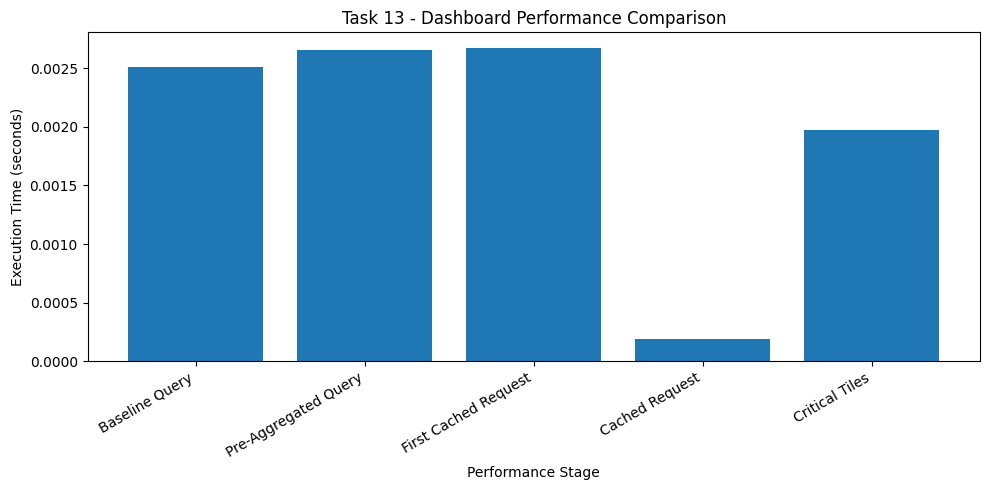

In [22]:
# Performance comparison chart

plt.figure(figsize=(10, 5))

plt.bar(
    final_summary["Optimization"],
    final_summary["Time_Seconds"]
)

plt.ylabel("Execution Time (seconds)")
plt.xlabel("Performance Stage")
plt.title("Task 13 - Dashboard Performance Comparison")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Task 13 — Final Conclusion

The Dashboard Performance Tuning task focused on improving query efficiency and dashboard responsiveness using a reproducible Python and SQL environment.

The baseline query was first measured and its execution plan was examined using SQL EXPLAIN QUERY PLAN. A pre-aggregated sales summary table was then created to reduce repeated aggregation work.

Indexes were added to frequently used filtering and grouping columns. Query caching was also implemented so repeated dashboard requests could reuse previously calculated results instead of executing the same query again.

The dashboard loading strategy was further improved by prioritizing critical KPI tiles such as Total Net Sales, Total Orders, and Total Quantity, while secondary analytical tiles were loaded separately.

Before-and-after execution times were recorded to provide measurable evidence of the optimization process.

## Key Optimizations
- SQL query profiling using EXPLAIN QUERY PLAN
- Pre-aggregated sales summary table
- Indexes on frequently accessed columns
- Query caching for repeated requests
- Critical KPI tiles loaded before secondary tiles
- Before/after performance measurement

## Conclusion

The exercise demonstrated that dashboard performance can be improved by reducing repeated computation, preparing frequently used aggregations in advance, indexing commonly accessed columns, caching repeated queries, and prioritizing critical dashboard content.

Because the demonstration dataset is relatively small, the performance differences may be limited by the dataset size and local execution overhead. The optimization techniques become increasingly valuable as data volume and dashboard query complexity grow.